In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sns

In [2]:
df_train= pd.read_csv("C:/Users/User/Desktop/BigMartMacinelearning/Train.csv")

In [3]:
df_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
df_train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [6]:
missing_values = df_train.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Sadece eksik değeri olanları al

print(missing_values)

Item_Weight    1463
Outlet_Size    2410
dtype: int64


In [7]:
df_train.shape

(8523, 12)

In [8]:
df_train.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [9]:
df_train["Item_Fat_Content"].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [10]:
df_train["Item_Type"].unique()

array(['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables',
       'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods',
       'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned',
       'Breads', 'Starchy Foods', 'Others', 'Seafood'], dtype=object)

In [11]:
df_train["Outlet_Size"].unique()

array(['Medium', nan, 'High', 'Small'], dtype=object)

In [12]:
df_train["Outlet_Location_Type"].unique()

array(['Tier 1', 'Tier 3', 'Tier 2'], dtype=object)

In [13]:
df_train["Outlet_Type"].unique()

array(['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
       'Supermarket Type3'], dtype=object)

In [14]:
df_train["Item_Weight"].min()

4.555

In [15]:
df_train["Item_Weight"].max()

21.35

In [16]:
df_train["Item_Outlet_Sales"].min()

33.29

In [17]:
df_train["Item_Outlet_Sales"].max()

13086.9648

In [18]:
df_train.groupby("Item_Type")["Item_Outlet_Sales"].mean().sort_values(ascending=False)
# .sort_values(ascending=False) büyükten küçüğe sıraladım.

Item_Type
Starchy Foods            2374.332773
Seafood                  2326.065928
Fruits and Vegetables    2289.009592
Snack Foods              2277.321739
Household                2258.784300
Dairy                    2232.542597
Canned                   2225.194904
Breads                   2204.132226
Meat                     2158.977911
Hard Drinks              2139.221622
Frozen Foods             2132.867744
Breakfast                2111.808651
Health and Hygiene       2010.000265
Soft Drinks              2006.511735
Baking Goods             1952.971207
Others                   1926.139702
Name: Item_Outlet_Sales, dtype: float64

In [19]:
df_train.groupby("Outlet_Type")["Item_Outlet_Sales"].mean().sort_values(ascending=False)

Outlet_Type
Supermarket Type3    3694.038558
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Grocery Store         339.828500
Name: Item_Outlet_Sales, dtype: float64

In [20]:
sales = df_train.groupby("Outlet_Type")["Item_Outlet_Sales"].sum().sort_values(ascending=False)
sales = sales.apply(lambda x: f"{x:,.0f}")
print(sales)


Outlet_Type
Supermarket Type1    12,917,342
Supermarket Type3     3,453,926
Supermarket Type2     1,851,823
Grocery Store           368,034
Name: Item_Outlet_Sales, dtype: object


In [21]:
df_train.groupby("Outlet_Location_Type")["Item_Outlet_Sales"].mean().sort_values(ascending=False)

Outlet_Location_Type
Tier 2    2323.990559
Tier 3    2279.627651
Tier 1    1876.909159
Name: Item_Outlet_Sales, dtype: float64

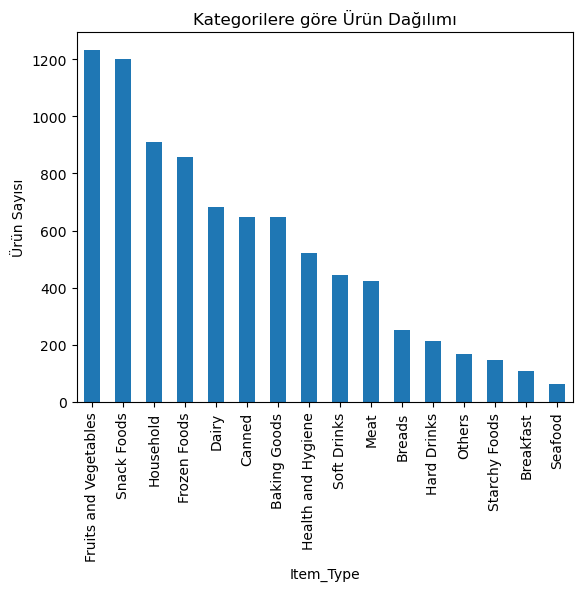

In [22]:
import matplotlib.pyplot as plt

df_train["Item_Type"].value_counts().plot(kind="bar")
plt.xlabel("Item_Type")
plt.ylabel("Ürün Sayısı")
plt.title("Kategorilere göre Ürün Dağılımı")
plt.show()

In [23]:
import matplotlib.pyplot as plt


# Ortalama satışlar
avg_sales_by_type = df_train.groupby("Item_Type")["Item_Outlet_Sales"].mean().reset_index()




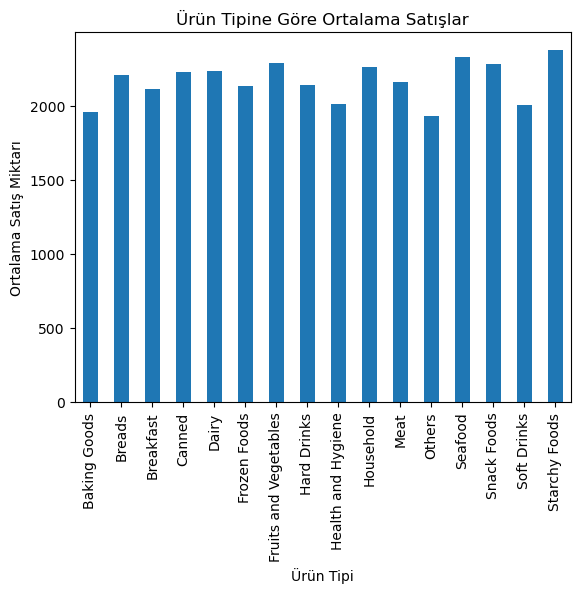

In [24]:
avg_sales_by_type.plot(kind="bar", x="Item_Type", y="Item_Outlet_Sales", legend=False)
plt.xlabel("Ürün Tipi")
plt.ylabel("Ortalama Satış Miktarı")
plt.title("Ürün Tipine Göre Ortalama Satışlar")
plt.xticks(rotation=90)  
plt.show()


In [25]:
# Aynı Item_Identifier'e sahip ürünlerin ortalama ağırlığı ile eksikleri dolduralım
df_train["Item_Weight"].fillna(df_train.groupby("Item_Identifier")["Item_Weight"].transform("mean"), inplace=True)




In [26]:
# Aynı Outlet_Type'e göre en sık geçen  değeri kullanarak eksikleri dolduralım
mode_outlet_size = df_train.pivot_table(values="Outlet_Size", index="Outlet_Type", aggfunc=lambda x: x.mode()[0])


missing_outlet_mask = df_train["Outlet_Size"].isnull()
df_train.loc[missing_outlet_mask, "Outlet_Size"] = df_train.loc[missing_outlet_mask, "Outlet_Type"].map(mode_outlet_size.to_dict()["Outlet_Size"])


In [27]:
df_train.isnull().sum()

Item_Identifier              0
Item_Weight                  4
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [28]:
df_train["Item_Weight"].fillna(df_train["Item_Weight"].mean(), inplace=True)

In [29]:
df_train.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [30]:
 # SATIŞ İNCELEME

In [31]:
# 1.  Genel Satış Dağılımını İnceleyelim
# İlk olarak Item_Outlet_Sales dağılımını histogram ile gösterelim. Böylece satışların hangi aralıkta yoğunlaştığını görebiliriz.

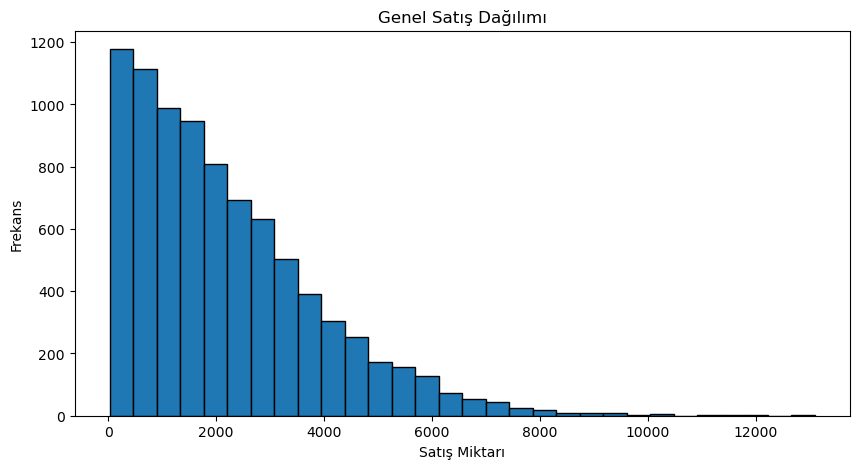

In [32]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
plt.hist(df_train["Item_Outlet_Sales"], bins=30, edgecolor='black')
plt.xlabel("Satış Miktarı")
plt.ylabel("Frekans")
plt.title("Genel Satış Dağılımı")
plt.show()


In [33]:
#1️. Genel Satış Dağılımı (Histogram)
#Satış dağılımı asimetrik (sağa çarpık) görünüyor.

#Düşük satış değerleri daha fazla, yüksek satış değerleri ise daha nadir.

#Çok yüksek satış yapan ürünler az sayıda olabilir, bu yüzden outlier (aykırı değer) kontrolü gerekebilir.




In [34]:
#2. Ürün Tiplerine Göre Ortalama Satışlar
#Ürün tipine göre ortalama satış miktarlarını çubuk grafikle gösterelim.

In [35]:
import seaborn as sns

# Ürün tiplerine göre ortalama satışlar
avg_sales_by_type = df_train.groupby("Item_Type")["Item_Outlet_Sales"].mean().reset_index()




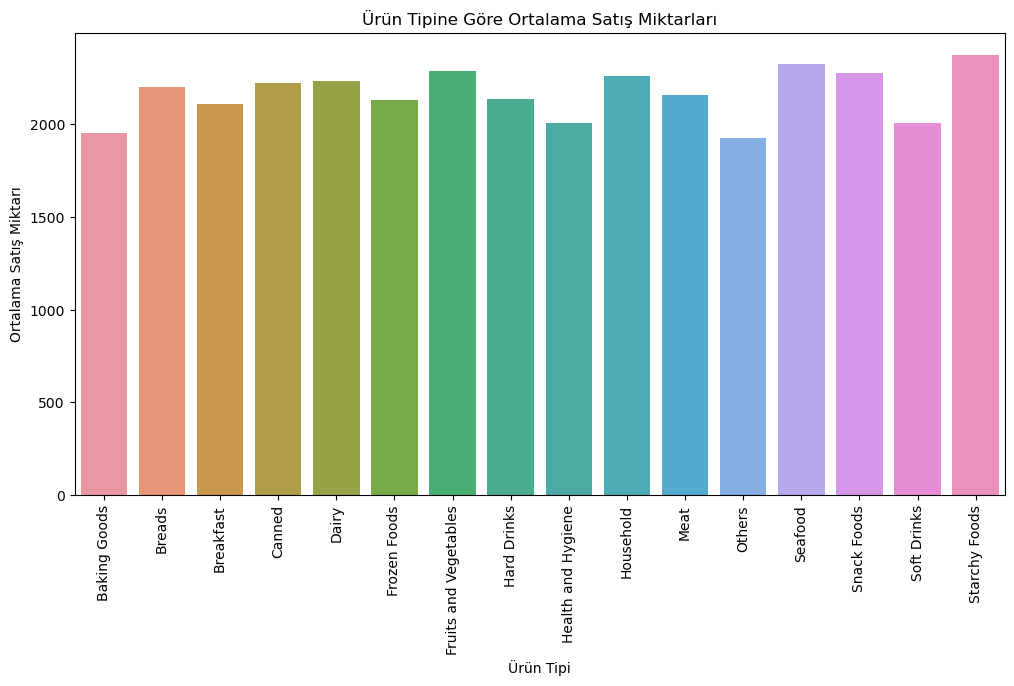

In [36]:
plt.figure(figsize=(12,6))
sns.barplot(data=avg_sales_by_type, x="Item_Type", y="Item_Outlet_Sales")
plt.xticks(rotation=90) 
plt.xlabel("Ürün Tipi")
plt.ylabel("Ortalama Satış Miktarı")
plt.title("Ürün Tipine Göre Ortalama Satış Miktarları")
plt.show()


In [37]:
# 2️. Ürün Tiplerine Göre Ortalama Satış Miktarları
# Bazı ürünler çok daha fazla satılıyor, bazıları ise düşük satışta kalıyor.

# En yüksek satış yapan ürün grubu "Starchy Foods" gibi görünüyor.

# Düşük satış yapan gruplar arasında ise "Health and Hygiene" ürünleri ve "Baking Goods" ve "Others"



In [38]:
# 3.Mağaza Türüne Göre Satışlar
# Farklı mağaza türlerinde satışların nasıl değiştiğini inceleyelim.

In [39]:
# Mağaza türlerine göre ortalama satışlar
avg_sales_by_outlet = df_train.groupby("Outlet_Type")["Item_Outlet_Sales"].mean().reset_index()


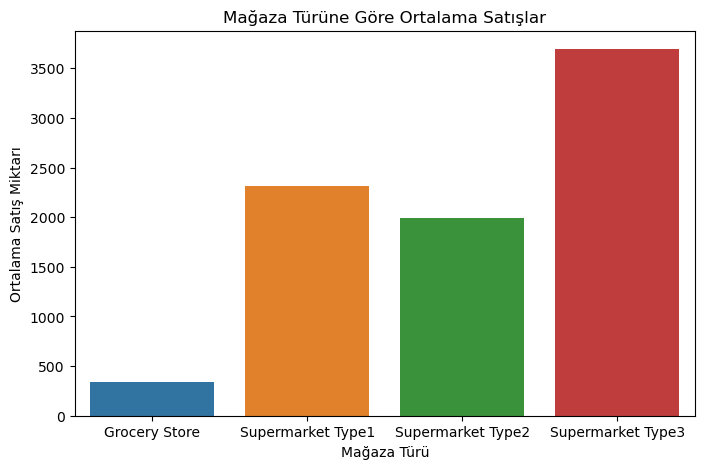

In [40]:


plt.figure(figsize=(8,5))
sns.barplot(data=avg_sales_by_outlet, x="Outlet_Type", y="Item_Outlet_Sales")
plt.xlabel("Mağaza Türü")
plt.ylabel("Ortalama Satış Miktarı")
plt.title("Mağaza Türüne Göre Ortalama Satışlar")
plt.show()


In [41]:
#3️. Mağaza Türüne Göre Ortalama Satışlar
#Hipermarketler (Supermarket Type3) açık ara farkla en yüksek satışa sahip.

#Süpermarket Type1 ve Type2 daha düşük satışlar yapıyor.

#Büyük mağazalar (hipermarketler) daha fazla satış yapıyor.

#Outlet_Type değişkeni önemli bir özellik olabilir!


In [42]:
#4️. Ürün Fiyatı (Item_MRP) ile Satış İlişkisi
# Ürünlerin fiyatı arttıkça satışlar nasıl değişiyor? 

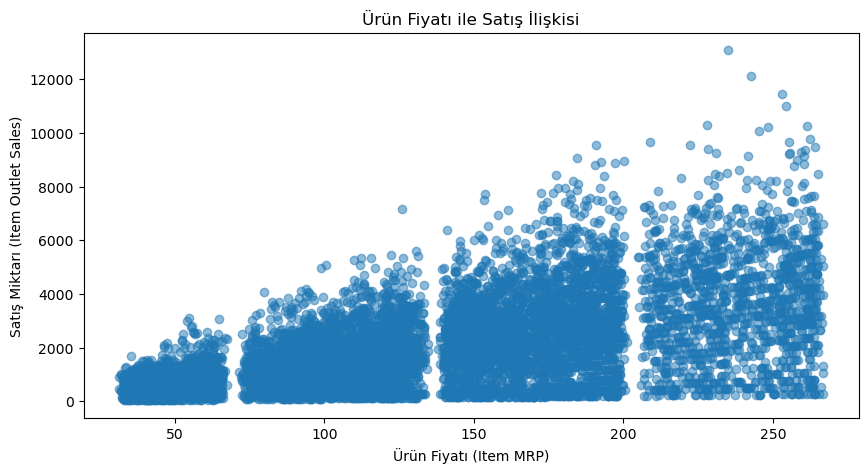

In [43]:

plt.figure(figsize=(10,5))
plt.scatter(df_train["Item_MRP"], df_train["Item_Outlet_Sales"], alpha=0.5)
plt.xlabel("Ürün Fiyatı (Item MRP)")
plt.ylabel("Satış Miktarı (Item Outlet Sales)")
plt.title("Ürün Fiyatı ile Satış İlişkisi")
plt.show()


In [44]:
#4️. Ürün Fiyatı ile Satış İlişkisi
#Düşük fiyatlı ürünler genellikle daha fazla satılıyor.

#Ancak fiyat arttıkça satış miktarında düzenli bir azalma yok.

#Belli fiyat aralıklarında satışlar daha yoğun (örneğin 100-150 fiyat aralığı).

#Fiyat, satışları etkiliyor ancak doğrudan bir doğrusal ilişki yok.



In [45]:
df_train[["Item_MRP", "Item_Outlet_Sales"]].corr()


,Item_MRP,Item_Outlet_Sales
Item_MRP,1.000000,0.567574
Item_Outlet_Sales,0.567574,1.000000


In [46]:
# satış fiyatları artıkça satış artıyor gibi görünüyor ama bu bilgi tek başına yeterli değil

In [47]:
# Model İçin Hangi Özellikleri Kullanmalıyız?
# Önemli sütunlar

#Item_Type (Ürün kategorisi)

#Outlet_Type (Mağaza türü)

#Item_MRP (Ürün fiyatı)

In [48]:
# MAĞAZA YAŞI

In [49]:
df_train["Outlet_Age"] = 2024 - df_train["Outlet_Establishment_Year"]


In [50]:
df_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,25
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,15
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,25
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,26
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,37


In [51]:
#Item_Fat_Content de 'Low Fat', 'Regular', 'low fat', 'LF', 'reg'değerlerini düzeltelim.

In [52]:
df_train["Item_Fat_Content"] = df_train["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})


In [53]:
df_train["Item_Fat_Content"].unique()

array(['Low Fat', 'Regular'], dtype=object)

In [54]:
# Item_Visibility kontrol
#Item_Visibility = Ürünün Raf Alanı / Toplam Mağaza Raf Alanı


In [55]:
df_train[df_train["Item_Visibility"] <= 0 ]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
3,FDX07,19.200,Regular,0.0,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,26
4,NCD19,8.930,Low Fat,0.0,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,37
5,FDP36,10.395,Regular,0.0,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088,15
10,FDY07,11.800,Low Fat,0.0,Fruits and Vegetables,45.5402,OUT049,1999,Medium,Tier 1,Supermarket Type1,1516.0266,25
32,FDP33,18.700,Low Fat,0.0,Snack Foods,256.6672,OUT018,2009,Medium,Tier 3,Supermarket Type2,3068.0064,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8480,FDQ58,7.315,Low Fat,0.0,Snack Foods,154.5340,OUT019,1985,Small,Tier 1,Grocery Store,459.4020,39
8484,DRJ49,6.865,Low Fat,0.0,Soft Drinks,129.9652,OUT013,1987,High,Tier 3,Supermarket Type1,2324.9736,37
8486,FDR20,20.000,Regular,0.0,Fruits and Vegetables,46.4744,OUT010,1998,Small,Tier 3,Grocery Store,45.2744,26
8494,NCI54,15.200,Low Fat,0.0,Household,110.4912,OUT017,2007,Small,Tier 2,Supermarket Type1,1637.8680,17


In [56]:
(df_train["Item_Visibility"] <= 0).sum()

526

In [57]:
# 526 satırda ürün görünürlüğü 0 bu yüzden satışı yapılmış mı kontrol edeceğiz. Hepsinin satışı yapılmış. Yani yanlış girilmiş
# 0 olmaması lazım

In [58]:
df_train[(df_train["Item_Visibility"] == 0) & (df_train["Item_Outlet_Sales"] == 0)]


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age


In [59]:
# Bu değerleri ürün bazlı ortalama görünürlükle dolduralım

In [60]:
# Ürün bazlı ortalama görünürlük 
visibility_mean = df_train.groupby("Item_Identifier")["Item_Visibility"].transform("mean")

In [61]:


# Görünürlüğü 0 olanlara ortalama atadık
df_train.loc[df_train["Item_Visibility"] == 0, "Item_Visibility"] = visibility_mean


In [62]:
df_train[df_train["Item_Identifier"] == "FDX07"]


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
3,FDX07,19.2,Regular,0.015274,Fruits and Vegetables,182.095,OUT010,1998,Small,Tier 3,Grocery Store,732.380,26
1491,FDX07,19.2,Regular,0.022914,Fruits and Vegetables,181.195,OUT035,2004,Small,Tier 2,Supermarket Type1,2380.235,20
2459,FDX07,19.2,Regular,0.022965,Fruits and Vegetables,181.695,OUT045,2002,Small,Tier 2,Supermarket Type1,2563.330,22
3089,FDX07,19.2,Regular,0.015274,Fruits and Vegetables,184.595,OUT018,2009,Medium,Tier 3,Supermarket Type2,3844.995,15
5906,FDX07,19.2,Regular,0.022954,Fruits and Vegetables,184.495,OUT049,1999,Medium,Tier 1,Supermarket Type1,4028.090,25
7735,FDX07,19.2,Regular,0.022808,Fruits and Vegetables,183.495,OUT027,1985,Medium,Tier 3,Supermarket Type3,4577.375,39


In [63]:
# kontrol
(df_train["Item_Visibility"] == 0).sum()



0

In [64]:
df_train["Item_Visibility"].describe()


count    8523.000000
mean        0.069670
std         0.049810
min         0.003575
25%         0.031114
50%         0.056922
75%         0.097160
max         0.328391
Name: Item_Visibility, dtype: float64

In [65]:
# item_MRP veriyi eşit sayıda gözleme böldük

In [66]:
df_train["Item_MRP"].describe()

count    8523.000000
mean      140.992782
std        62.275067
min        31.290000
25%        93.826500
50%       143.012800
75%       185.643700
max       266.888400
Name: Item_MRP, dtype: float64

In [67]:
# Minimum fiyat: 31 TL
# Ortalama: 140 TL
# Çeyreklikler:
# %25’i 94 TL'den az
# %50’si 143 TL'den az
# %75’i 185 TL'den az
# Ürünlerin çoğunluğu 100–200 TL bandında
# Aşırı düşük veya yüksek fiyatlı ürün sayısı az


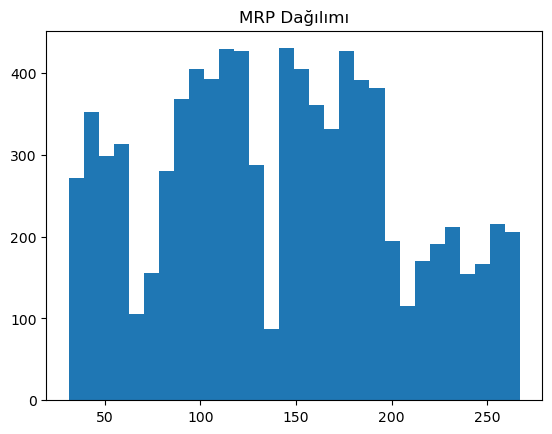

In [68]:
plt.hist(df_train["Item_MRP"], bins=30)
plt.title("MRP Dağılımı")
plt.show()

In [69]:
bins = [0, 90, 140, 200, 300]
labels = ["Low", "Medium", "High", "Very High"]

df_train["Item_MRP_Range"] = pd.cut(df_train["Item_MRP"], bins=bins, labels=labels)


In [70]:
#her segmentte kaç ürün var?
df_train["Item_MRP_Range"].value_counts()


Item_MRP_Range
High         2964
Medium       2150
Low          1969
Very High    1440
Name: count, dtype: int64

In [71]:
df_train.groupby("Item_MRP_Range")["Item_Outlet_Sales"].mean()
#segmentlere göre ortalama satış miktarı

C:\Users\User\AppData\Local\Temp\ipykernel_28640\787157385.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train.groupby("Item_MRP_Range")["Item_Outlet_Sales"].mean()


Item_MRP_Range
Low           909.098333
Medium       1721.462132
High         2632.411243
Very High    3678.819642
Name: Item_Outlet_Sales, dtype: float64

In [72]:
df_train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_MRP_Range
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,25,Very High
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,15,Low
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,25,High
3,FDX07,19.20,Regular,0.015274,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,26,High
4,NCD19,8.93,Low Fat,0.008082,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,37,Low


In [73]:

#Item_MRP	Satış fiyatı ; doğrudan etkili
#Item_Visibility	Raf görünürlüğü ;satış potansiyelini etkileyebilir
#Item_Type	Ürün türü ;talep farklılıkları
#Outlet_Type	Mağaza tipi ; büyük/küçük satış farkı
#Outlet_Location_Type	Bölge ; şehir, köy, kasaba etkisi olabilir
#Outlet_Size	Mağaza büyüklüğü ; stok ve satış etkisi
#Outlet_Establishment_Year	 deneyimli mağazalar daha çok satıyor olabilir mi?


In [74]:
df_train["Outlet_Identifier"].unique()

array(['OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027', 'OUT045',
       'OUT017', 'OUT046', 'OUT035', 'OUT019'], dtype=object)

In [75]:
# One-Hot-Encoding

In [76]:
columns_to_encode = [
    "Item_Fat_Content",
    "Outlet_Identifier",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type",
    "Item_MRP_Range",
    "Item_Type" 
]

df_encoded = pd.get_dummies(df_train, columns=columns_to_encode)


In [77]:
df_encoded.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Outlet_Age,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Identifier_OUT010,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,FDA15,9.30,0.016047,249.8092,1999,3735.1380,25,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,DRC01,5.92,0.019278,48.2692,2009,443.4228,15,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,FDN15,17.50,0.016760,141.6180,1999,2097.2700,25,True,False,False,...,False,False,False,False,True,False,False,False,False,False
3,FDX07,19.20,0.015274,182.0950,1998,732.3800,26,False,True,True,...,True,False,False,False,False,False,False,False,False,False
4,NCD19,8.93,0.008082,53.8614,1987,994.7052,37,True,False,False,...,False,False,False,True,False,False,False,False,False,False


In [78]:
#Outlet_Establishment_Year bu sütunu siliyoruz çünkü Outlet_Age adlı bir sutun yaptık . bu iki sütun birbirini kötü etkileyebilir 
# zaten kuruluş yılının da modelimiz için bir anlamı yok

In [79]:
df_encoded.drop("Outlet_Establishment_Year", axis=1, inplace=True)


In [80]:
df_encoded.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Age,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Identifier_OUT010,Outlet_Identifier_OUT013,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,FDA15,9.30,0.016047,249.8092,3735.1380,25,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,DRC01,5.92,0.019278,48.2692,443.4228,15,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,FDN15,17.50,0.016760,141.6180,2097.2700,25,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,FDX07,19.20,0.015274,182.0950,732.3800,26,False,True,True,False,...,True,False,False,False,False,False,False,False,False,False
4,NCD19,8.93,0.008082,53.8614,994.7052,37,True,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [81]:
# bu Item_Identifier sütun gereksiz encoding yapılamaz ve text halinde o yüzden siliyoruz
df_encoded.drop("Item_Identifier", axis=1, inplace=True)


In [82]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item_Weight                      8523 non-null   float64
 1   Item_Visibility                  8523 non-null   float64
 2   Item_MRP                         8523 non-null   float64
 3   Item_Outlet_Sales                8523 non-null   float64
 4   Outlet_Age                       8523 non-null   int64  
 5   Item_Fat_Content_Low Fat         8523 non-null   bool   
 6   Item_Fat_Content_Regular         8523 non-null   bool   
 7   Outlet_Identifier_OUT010         8523 non-null   bool   
 8   Outlet_Identifier_OUT013         8523 non-null   bool   
 9   Outlet_Identifier_OUT017         8523 non-null   bool   
 10  Outlet_Identifier_OUT018         8523 non-null   bool   
 11  Outlet_Identifier_OUT019         8523 non-null   bool   
 12  Outlet_Identifier_OU

In [83]:
#tüm satırları float yapıyoruz
df_encoded = df_encoded.astype(float)


In [84]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item_Weight                      8523 non-null   float64
 1   Item_Visibility                  8523 non-null   float64
 2   Item_MRP                         8523 non-null   float64
 3   Item_Outlet_Sales                8523 non-null   float64
 4   Outlet_Age                       8523 non-null   float64
 5   Item_Fat_Content_Low Fat         8523 non-null   float64
 6   Item_Fat_Content_Regular         8523 non-null   float64
 7   Outlet_Identifier_OUT010         8523 non-null   float64
 8   Outlet_Identifier_OUT013         8523 non-null   float64
 9   Outlet_Identifier_OUT017         8523 non-null   float64
 10  Outlet_Identifier_OUT018         8523 non-null   float64
 11  Outlet_Identifier_OUT019         8523 non-null   float64
 12  Outlet_Identifier_OU

In [85]:
# y hedef değişkenimiz tahmin etmek istediğimiz değerleri temsil ediyor.

In [86]:
y = df_encoded["Item_Outlet_Sales"]


In [87]:
# x ise tahmin için kullanacağımız diğer sütunları temsil ediyor.
# modelin "satışı neye göre tahmin etmesi" gerektiği tüm bilgilerdir.



In [88]:
X = df_encoded.drop("Item_Outlet_Sales", axis=1)


In [89]:
#Eğitim ve test setine ayırıyoruz; %80’i eğitim, %20’si test

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [91]:
#Linear Regression modelini kuralım

In [92]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [93]:
y_pred = model.predict(X_test)


In [94]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)


RMSE: 1068.8430862679636
R² Score: 0.5796769224596741


In [95]:
#	Yorum
#RMSE	1068 ;model hatayı makul seviyede yapıyor
#R²	0.57	;Orta seviye daha iyi hale getirilebilir


In [96]:
#Yeni bir model
#RandomForestRegressor

In [97]:
from sklearn.ensemble import RandomForestRegressor


In [98]:
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [99]:
y_pred_rf = model_rf.predict(X_test)


In [100]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)


Random Forest RMSE: 1075.1669336398552
Random Forest R²: 0.5746884966134025


In [101]:
#Modelin neye güvendiğine bakmak istiyorum

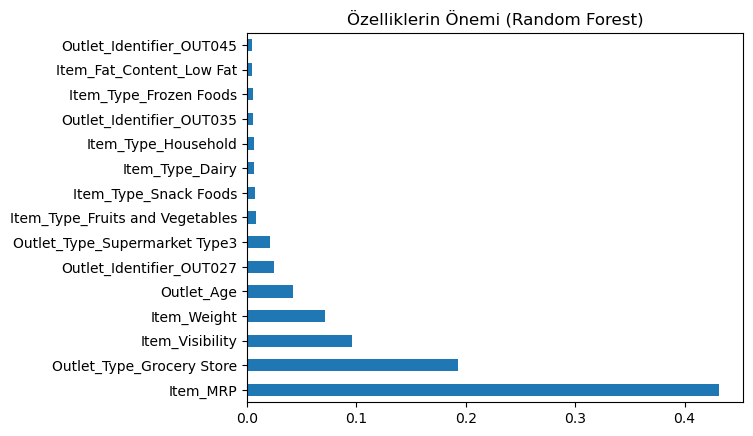

In [102]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importances = pd.Series(model_rf.feature_importances_, index=X.columns)
feature_importances.nlargest(15).plot(kind='barh')
plt.title("Özelliklerin Önemi (Random Forest)")
plt.show()


In [103]:
#Yüksek önem
#Item_MRP	Ürün fiyatı ;Model “fiyat ne kadar yüksekse satış da artabilir” gibi bir ilişki öğrenmiş
#Outlet_Type_Grocery Store	Mağaza türü  Belli mağaza türlerinde satış farklılığı fark etmiş
#Item_Visibility	Ürün ne kadar görünür. Çünkü Raflarda görünmeyen ürün satılmaz
#Item_Weight	Ürünün ağırlığı	 Orta seviye önemli  belki taşıma/ambalaj gibi etkiler olabilir
#Outlet_Age	Mağaza ne kadar süredir açık	 Model deneyimli mağazalara önem veriyor olabilir
#Düşük önem
#Item_Type_ → (örn. Dairy, Snack Foods...)	Model bu türleri pek ayırt edememiş
#Item_Fat_Content_Low Fat	Yağ oranının etkisi düşük görünmüş
#Outlet_Identifier_	Belirli şubeler fark yaratmamış

In [104]:
# test verisini yükleyip temizliyoruz.

In [105]:
df_test= pd.read_csv("C:/Users/User/Desktop/BigMartMacinelearning/Test.csv")

In [106]:
df_test.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [107]:
df_test.shape

(5681, 11)

In [108]:
df_test.isnull().sum()

Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

In [109]:
df_test["Item_Fat_Content"].unique()

array(['Low Fat', 'reg', 'Regular', 'LF', 'low fat'], dtype=object)

In [110]:
df_test["Item_Fat_Content"] = df_test["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})


In [111]:
df_test["Outlet_Age"] = 2024 - df_test["Outlet_Establishment_Year"]



In [112]:
visibility_mean = df_train.groupby("Item_Identifier")["Item_Visibility"].transform("mean")
df_test.loc[df_test["Item_Visibility"] == 0, "Item_Visibility"] = visibility_mean


In [113]:
bins = [0, 90, 140, 200, 300]
labels = ["Low", "Medium", "High", "Very High"]
df_test["Item_MRP_Range"] = pd.cut(df_test["Item_MRP"], bins=bins, labels=labels)


In [114]:
df_test["Item_Weight"].fillna(df_train.groupby("Item_Identifier")["Item_Weight"].transform("mean"), inplace=True)
df_test["Item_Weight"].fillna(df_train["Item_Weight"].mean(), inplace=True)

mode_outlet_size = df_train.pivot_table(values="Outlet_Size", index="Outlet_Type", aggfunc=lambda x: x.mode()[0])
missing_outlet_mask = df_test["Outlet_Size"].isnull()
df_test.loc[missing_outlet_mask, "Outlet_Size"] = df_test.loc[missing_outlet_mask, "Outlet_Type"].map(mode_outlet_size.to_dict()["Outlet_Size"])


In [115]:
combined = pd.concat([df_train.drop("Item_Outlet_Sales", axis=1), df_test])
combined_encoded = pd.get_dummies(combined, columns=[
    "Item_Fat_Content", "Outlet_Identifier", "Outlet_Size",
    "Outlet_Location_Type", "Outlet_Type", "Item_MRP_Range", "Item_Type"
])


In [116]:
combined_encoded.drop("Item_Identifier", axis=1, inplace=True)


In [117]:
combined_encoded.fillna(combined_encoded.mean(), inplace=True)


In [118]:

X_test_final = combined_encoded.iloc[df_train.shape[0]:, :]
X_test_final.drop(["Outlet_Establishment_Year"], axis=1, inplace=True)

X_train_final = combined_encoded.iloc[:df_train.shape[0], :].drop(["Outlet_Establishment_Year"], axis=1)
y_train = df_train["Item_Outlet_Sales"]


C:\Users\User\AppData\Local\Temp\ipykernel_28640\2179699868.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_final.drop(["Outlet_Establishment_Year"], axis=1, inplace=True)


In [119]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train_final, y_train)


RandomForestRegressor(random_state=42)

In [120]:
y_pred_test = model.predict(X_test_final)


In [121]:
submission = df_test[["Item_Identifier", "Outlet_Identifier"]].copy()
submission["Item_Outlet_Sales"] = y_pred_test
submission.to_csv("submission.csv", index=False)


In [122]:
import os
os.getcwd()



'C:\\Users\\User\\Desktop\\BigMartMacinelearning'